# 4-D phase space reconstruction with `ResNNTransform`
This is a copy of [`example_reconstruction_4d.ipynb`](example_reconstruction_4d.ipynb) that swaps in `gpsr.beams.ResNNTransform` -- a residual-network beam transformer that first applies a linear transformation to the base distribution and then adds a learned nonlinear residual -- in place of the default `NNTransform`. It also compares the linear (first-layer) prediction and the final reconstructed beam distribution to the ground-truth distribution used to generate the training data, similar to `dev/skip_connection.ipynb`.

### Python package imports

In [1]:
import numpy as np
import torch
import lightning as L
from cheetah.particles import ParticleBeam
from gpsr.modeling import GPSR, GPSRQuadScanLattice
from gpsr.train import LitGPSR
from gpsr.beams import NNParticleBeamGenerator, ResNNTransform
from gpsr.datasets import QuadScanDataset, split_dataset

### Load data

Load measurment dataset and split into train and test datasets

torch.Size([20, 1]) torch.Size([20, 100, 100]) Screen(name='unnamed_element_4', resolution=(100, 100), pixel_size=tensor([1.0000e-04, 1.0000e-04]), binning=1, misalignment=tensor([0., 0.]), method='kde', kde_bandwidth=tensor(1.0000e-04), is_active=True)


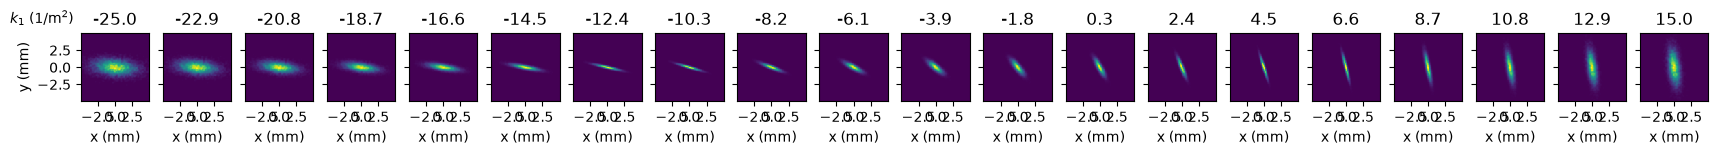

In [2]:
dset = torch.load(
    "example_data/example_datasets/reconstruction_gaussian_4D.dset", weights_only=False
)
print(
    dset.parameters.shape,
    dset.observations[0].shape,
    dset.screen,
)
dset.plot_data();

In [3]:
train_k_ids = np.arange(0, len(dset.parameters), 2)
train_dset, test_dset = split_dataset(dset, train_k_ids)

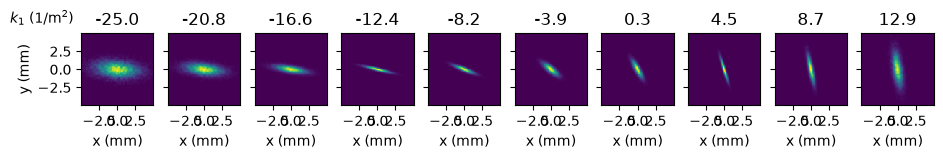

In [4]:
train_dset.plot_data();

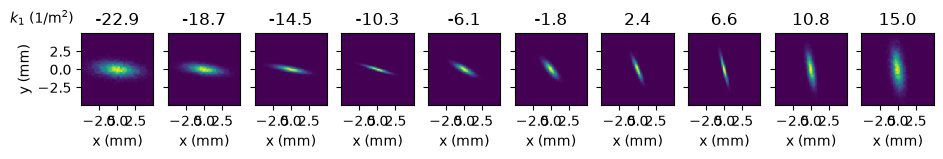

In [5]:
test_dset.plot_data();

### Create the quadrupole scan lattice
Here we use the differentiable Cheetah `Screen`. This screen uses kernel desity estimation to approximate the histogram in order to make it differentiable and vectorized.

In [6]:
# print screen information
print(train_dset.screen)
# create diagnostic lattice
p0c = 43.36e6  # reference momentum in eV/c
gpsr_lattice = GPSRQuadScanLattice(l_quad=0.1, l_drift=1.0, screen=train_dset.screen)

Screen(name='unnamed_element_4', resolution=(100, 100), pixel_size=tensor([1.0000e-04, 1.0000e-04]), binning=1, misalignment=tensor([0., 0.]), method='kde', kde_bandwidth=tensor(1.0000e-04), is_active=True)


### Define the GPSR model for training
The GPSR model contains the ML-based parameterization of the initial beam distribution `NNParticleBeamGenerator` with 10k particles, using `ResNNTransform` (with a skip connection) as its transformer, and the differentiable simulation of the diagnostic lattice (same one used above to generate the training data).

In [7]:
transformer = ResNNTransform(
    n_hidden=2, width=20, phase_space_dim=4, use_skip_connection=True
)
gpsr_model = GPSR(
    NNParticleBeamGenerator(10000, p0c, transformer=transformer, n_dim=4), gpsr_lattice
)
train_loader = torch.utils.data.DataLoader(train_dset, batch_size=10)

litgpsr = LitGPSR(gpsr_model)
logger = L.pytorch.loggers.TensorBoardLogger(
    ".",
)

### Perform the reconstruction
This cell performs the reconstruction by varying the parameters of `NNParticleBeamGenerator` to minimize the difference between predicted measurements and the training data. This step will take some time on a CPU but can be greatly accelerated (1-2 orders of magnitude) if using a GPU to do the computation. If you are limited to a CPU I would recommend reducing the number of `max_epochs` to be between 500-1000 to reduce computation time.

In [8]:
trainer = L.Trainer(limit_train_batches=100, max_epochs=500, logger=logger)
trainer.fit(model=litgpsr, train_dataloaders=train_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type | Params | Mode  | FLOPs
----------------------------------------------------
0 | gpsr_model | GPSR | 626    | train | 0    
----------------------------------------------------
626       Trainable params
0         Non-trainable params
626       Total params
0.003     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
0         Total Flops
/home/rroussel/miniforge3/e

Epoch 499: 100%|██████████| 1/1 [00:00<00:00, 20.42it/s, v_num=115]

`Trainer.fit` stopped: `max_epochs=500` reached.


Epoch 499: 100%|██████████| 1/1 [00:00<00:00,  8.22it/s, v_num=115]


### Get the reconstructed beam distribution

In [9]:
reconstructed_beam = litgpsr.gpsr_model.beam_generator()

### Evaluate model on samples to compare predictions
Here we use the trained GPSR model to make predictions that should agree with the training data. The plot below shows the training data as the colormap and uses contour lines to show the predicted measurements at the 10th, 50th, 95th percentiles.

In [10]:
test_pred = gpsr_model(test_dset.parameters)[0].detach()
test_pred_dset = QuadScanDataset(test_dset.parameters, (test_pred,), train_dset.screen)

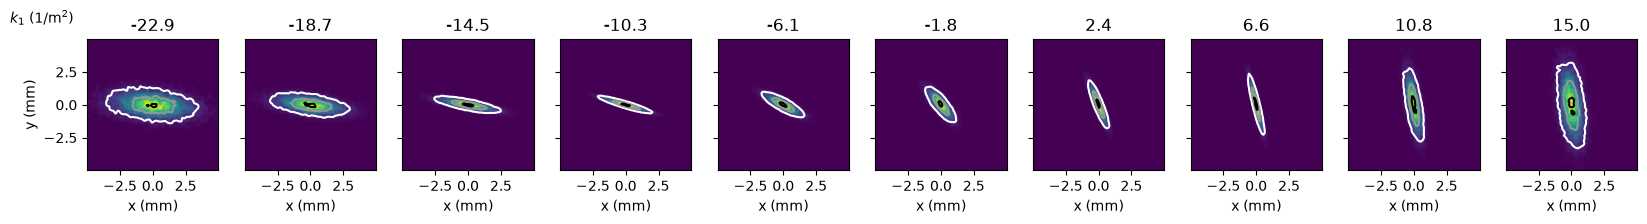

In [11]:
fig, ax = test_dset.plot_data(overlay_data=test_pred_dset)
fig.set_size_inches(20, 3)

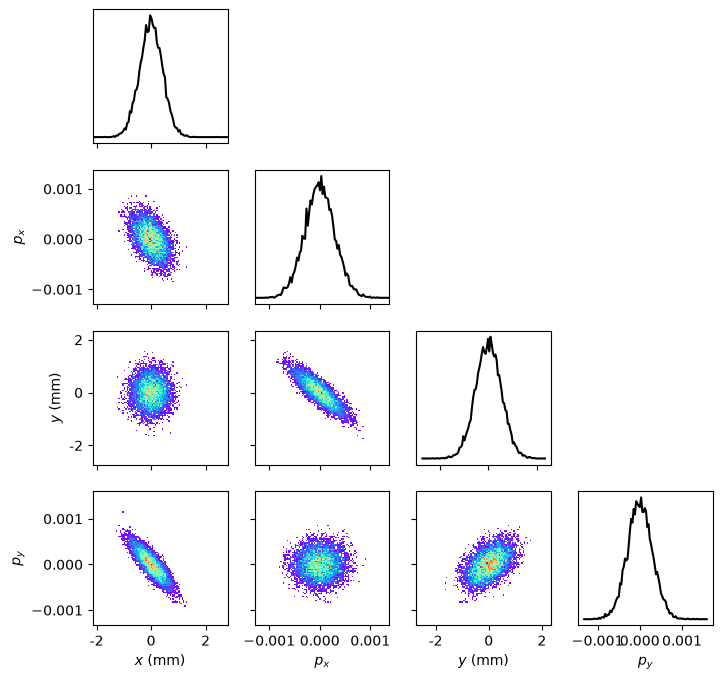

In [12]:
reconstructed_beam.plot_distribution(dimensions=("x", "px", "y", "py"));

### Compare the linear prediction and reconstruction to the ground truth
`ResNNTransform` first applies a linear transformation (`transformer.linear_forward`) to the base distribution before adding the residual network's nonlinear contribution. Here we compare that linear-only prediction, as well as the final reconstructed beam, to the ground-truth distribution used to generate the training data.

In [13]:
trained_beam_generator = litgpsr.gpsr_model.beam_generator


def to_linear_beam(beam_generator: NNParticleBeamGenerator) -> ParticleBeam:
    """Embed a transformer's linear (first-layer) output into 6d phase space, as a ParticleBeam."""
    transformer = beam_generator.transformer
    with torch.no_grad():
        linear_output = (
            transformer.linear_forward(beam_generator.base_particles)
            * transformer.output_scale
        )

    coords = torch.randn(linear_output.shape[0], 6) * 1e-7
    coords[:, : linear_output.shape[-1]] = linear_output
    coords = torch.cat((coords, torch.ones_like(coords[:, :1])), dim=-1)

    return ParticleBeam(
        particles=coords,
        energy=beam_generator.beam_energy,
        particle_charges=beam_generator.particle_charges,
        survival_probabilities=beam_generator.survival_probabilities,
    )


linear_beam = to_linear_beam(trained_beam_generator)

# ground truth beam used to generate the training dataset
gt_beam = torch.load(
    "example_data/example_distributions/gaussian_beam.pt", weights_only=False
)
gt_beam = ParticleBeam(gt_beam.particles, gt_beam.energy)

dims = ("x", "px", "y", "py")

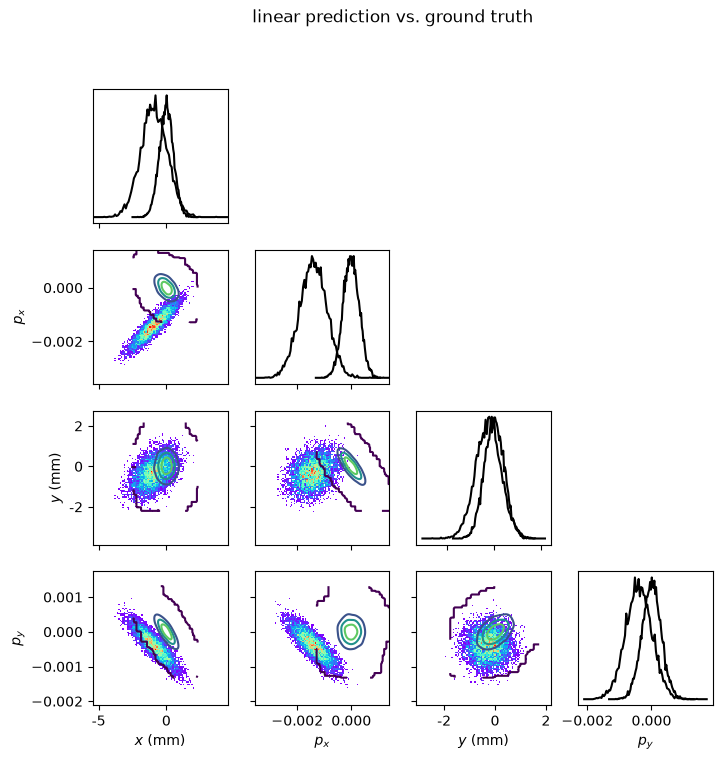

In [14]:
# compare the linear-only prediction to ground truth
fig, axs = linear_beam.plot_distribution(dimensions=dims)
gt_beam.plot_distribution(dimensions=dims, axs=axs, plot_2d_kws={"style": "contour"})
fig.suptitle("linear prediction vs. ground truth");

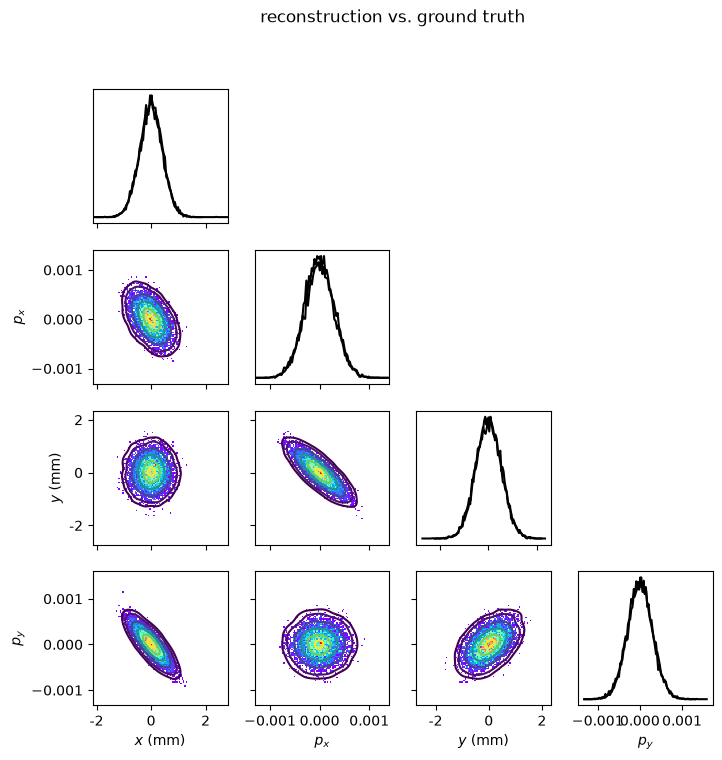

In [15]:
# compare the final reconstruction to ground truth
fig2, axs2 = reconstructed_beam.plot_distribution(dimensions=dims)
gt_beam.plot_distribution(
    dimensions=dims,
    axs=axs2,
    plot_2d_kws={
        "style": "contour",
        "contour_kws": {"levels": [0.05, 0.1, 0.25, 0.5, 0.75, 0.95]},
    },
)
fig2.suptitle("reconstruction vs. ground truth");